In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

c:\Users\Mushaf\Desktop\GenAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str


In [4]:

def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state


In [5]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state


In [6]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

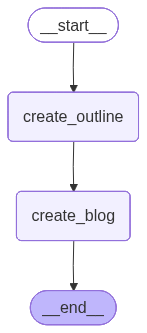

In [7]:
graph.compile()

In [10]:
workflow = graph.compile()
intial_state = {'title': 'Scope of AI in next 10 years'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Scope of AI in next 10 years', 'outline': 'Here\'s a detailed outline for a blog post on the "Scope of AI in the Next 10 Years," designed to be engaging, informative, and forward-looking.\n\n---\n\n## Blog Title Ideas:\n*   The AI Horizon: Unveiling the Scope of Artificial Intelligence in the Next Decade\n*   Beyond the Hype: What AI Will *Really* Achieve in the Next 10 Years\n*   Decoding Tomorrow: A Deep Dive into AI\'s Transformative Scope (2024-2034)\n*   The Decade of Intelligence: Navigating the Future Scope of AI\n*   From Assistants to Architects: The Expanding Scope of AI in the Next 10 Years\n\n---\n\n## Detailed Blog Outline: The AI Horizon: Unveiling the Scope of Artificial Intelligence in the Next Decade\n\n**Target Audience:** Tech enthusiasts, business leaders, students, general public interested in future trends.\n\n**Tone:** Optimistic yet realistic, informative, forward-looking, slightly speculative but grounded in current trends.\n\n---\n\n### I. Introduct